In [17]:
import pandas as pd
import numpy as np
import os
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
from google.colab import files
uploaded = files.upload()

Saving Stemmed_Veri_Seti.csv to Stemmed_Veri_Seti (1).csv
Saving Lemmatized_Veri_Seti.csv to Lemmatized_Veri_Seti (1).csv


In [20]:
lem_df = pd.read_csv("Lemmatized_Veri_Seti.csv").dropna()
stem_df = pd.read_csv("Stemmed_Veri_Seti.csv").dropna()

In [21]:
parameters = [
    ('cbow',2,100), ('skipgram',2,100),
    ('cbow',4,100), ('skipgram',4,100),
    ('cbow',2,300), ('skipgram',2,300),
    ('cbow',4,300), ('skipgram',4,300)
]

In [22]:
def train_models(df, prefix):
    os.makedirs("models", exist_ok=True)
    sentences = [str(x).split() for x in df.iloc[:,0]]

    for model_type, window, dim in parameters:
        sg = 1 if model_type == "skipgram" else 0

        model = Word2Vec(
            sentences=sentences,
            vector_size=dim,
            window=window,
            sg=sg,
            min_count=1,
            workers=2
        )

        name = f"{prefix}_{model_type}_w{window}_d{dim}.model"
        model.save("models/" + name)

        print("Saved:", name)

In [23]:
train_models(lem_df, "lem")
train_models(stem_df, "stem")

Saved: lem_cbow_w2_d100.model
Saved: lem_skipgram_w2_d100.model
Saved: lem_cbow_w4_d100.model
Saved: lem_skipgram_w4_d100.model
Saved: lem_cbow_w2_d300.model
Saved: lem_skipgram_w2_d300.model
Saved: lem_cbow_w4_d300.model
Saved: lem_skipgram_w4_d300.model
Saved: stem_cbow_w2_d100.model
Saved: stem_skipgram_w2_d100.model
Saved: stem_cbow_w4_d100.model
Saved: stem_skipgram_w4_d100.model
Saved: stem_cbow_w2_d300.model
Saved: stem_skipgram_w2_d300.model
Saved: stem_cbow_w4_d300.model
Saved: stem_skipgram_w4_d300.model


In [24]:
def get_vector(text, model):
    words = str(text).split()
    vecs = []

    for w in words:
        if w in model.wv:
            vecs.append(model.wv[w])

    if len(vecs) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vecs, axis=0)

In [25]:
def top5(model, df, query):
    q_vec = get_vector(query, model)
    results = []

    for text in df.iloc[:,0]:
        v = get_vector(str(text), model)
        score = cosine_similarity([q_vec], [v])[0][0]
        results.append((text, score))

    return sorted(results, key=lambda x: x[1], reverse=True)[:5]

In [26]:
all_results = {}

for file in os.listdir("models"):
    model = Word2Vec.load("models/" + file)

    if file.startswith("lem"):
        query = lem_df.iloc[0,0]
        all_results[file] = top5(model, lem_df, query)
    else:
        query = stem_df.iloc[0,0]
        all_results[file] = top5(model, stem_df, query)

print("Total models:", len(all_results))

Total models: 16


In [27]:
def jaccard(a,b):
    a,b = set(a), set(b)
    return len(a & b)/len(a | b) if len(a|b)>0 else 0

models = list(all_results.keys())
matrix = pd.DataFrame(index=models, columns=models)

for m1 in models:
    for m2 in models:
        s1 = [x[0] for x in all_results[m1]]
        s2 = [x[0] for x in all_results[m2]]
        matrix.loc[m1,m2] = jaccard(s1,s2)

matrix = matrix.astype(float)

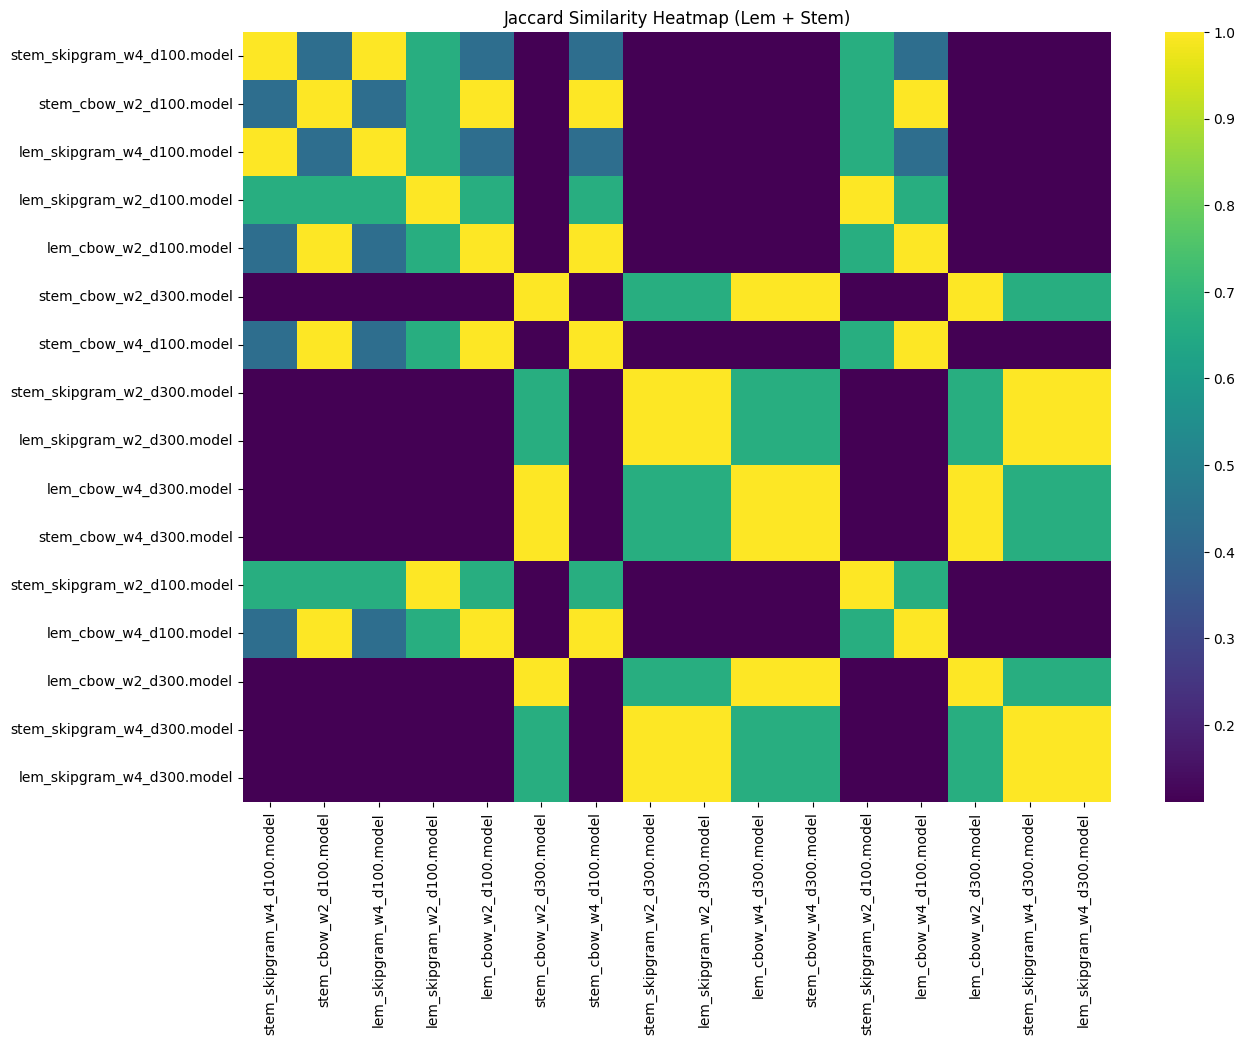

In [28]:
plt.figure(figsize=(14,10))
sns.heatmap(matrix, cmap="viridis")
plt.title("Jaccard Similarity Heatmap (Lem + Stem)")
plt.show()

In [29]:
print("Model sayısı:", len(all_results))
print("Örnek model:", list(all_results.keys())[:3])

Model sayısı: 16
Örnek model: ['stem_skipgram_w4_d100.model', 'stem_cbow_w2_d100.model', 'lem_skipgram_w4_d100.model']
